In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
data = pd.read_csv('Churn_Modelling.csv')

In [21]:
# Предварительный анализ данных
print(data.head())
print(data.info())
print(data.describe())

# Обработка данных
# Удалим ненужные столбцы (RowNumber, CustomerId, Surname)
data = data.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

   CreditScore  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0          619   42       2       0.00              1          1   
1          608   41       1   83807.86              1          0   
2          502   42       8  159660.80              3          1   
3          699   39       1       0.00              2          0   
4          850   43       2  125510.82              1          1   

   IsActiveMember  EstimatedSalary  Exited  Geography_Germany  \
0               1        101348.88       1              False   
1               1        112542.58       0              False   
2               0        113931.57       1              False   
3               0         93826.63       0              False   
4               1         79084.10       0              False   

   Geography_Spain  Gender_Male  
0            False        False  
1             True        False  
2            False        False  
3            False        False  
4             True        Fals

KeyError: "['RowNumber', 'CustomerId', 'Surname'] not found in axis"

In [6]:
# Разделение на признаки и целевую переменную
X = data.drop('Exited', axis=1)
y = data['Exited']

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Масштабирование числовых признаков
scaler = StandardScaler()
num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [7]:

# Базовая модель: Логистическая регрессия
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

# Предсказания и оценка модели
y_pred = log_reg.predict(X_test)
y_proba = log_reg.predict_proba(X_test)[:, 1]

print("\nОценка базовой модели (Логистическая регрессия):")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")


Оценка базовой модели (Логистическая регрессия):
Accuracy: 0.8080
Precision: 0.5891
Recall: 0.1867
F1-score: 0.2836
ROC-AUC: 0.7748


Проблемы модели:

1) Дисбаланс классов:

- Скорее всего, в данных много клиентов без оттока (класс 0) и мало - с оттоком (класс 1).

- Модель "учится" просто всегда предсказывать 0, что дает высокий Accuracy, но плохой Recall.

2) Недостаточная чувствительность к классу 1:

- Модель слишком консервативна в предсказании оттока.

3) Возможные причины:

- Недостаточно информативных признаков.

- Не учтены важные нелинейные зависимости.

- Требуется нормализация/стандартизация данных (если не была выполнена).

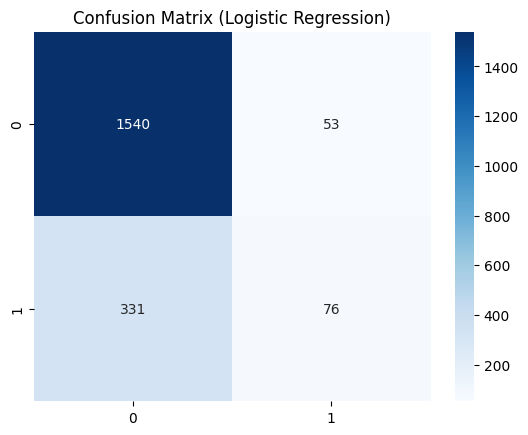


Важность признаков в логистической регрессии:
              Feature  Importance
8   Geography_Germany    0.819585
1                 Age    0.738453
3             Balance    0.161093
7     EstimatedSalary    0.047666
9     Geography_Spain    0.042508
2              Tenure   -0.020096
4       NumOfProducts   -0.070423
5           HasCrCard   -0.070516
0         CreditScore   -0.085893
10        Gender_Male   -0.523155
6      IsActiveMember   -1.028157


In [8]:

# Матрица ошибок
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Logistic Regression)')
plt.show()

# Анализ значимости признаков
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': log_reg.coef_[0]
}).sort_values('Importance', ascending=False)

print("\nВажность признаков в логистической регрессии:")
print(feature_importance)

Анализ важности признаков в логистической регрессии:

1) Топ-3 самых влиятельных признака:

- Geography_Germany (0.82): Клиенты из Германии имеют значительно более высокую вероятность оттока.

- Age (0.74): Возраст сильно влияет на отток - чем старше клиент, тем выше вероятность ухода.

- Balance (0.16): Клиенты с большим балансом на счетах более склонны уходить.

2) Негативно влияющие факторы (снижают вероятность оттока):

- IsActiveMember (-1.03): Активные клиенты гораздо реже уходят (самый сильный "удерживающий" фактор).

- Gender_Male (-0.52): Мужчины менее склонны к оттоку, чем женщины.

- CreditScore (-0.09): Клиенты с более высоким кредитным рейтингом немного реже уходят.

3) Незначимые факторы:

- Tenure (срок обслуживания) почти не влияет.

- Наличие кредитной карты (HasCrCard) минимально влияет.

In [9]:
# Улучшение модели: Отбор признаков
selector = SelectKBest(f_classif, k=8)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

selected_features = X.columns[selector.get_support()]
print("\nОтобранные признаки:", selected_features.tolist())


Отобранные признаки: ['CreditScore', 'Age', 'Balance', 'NumOfProducts', 'IsActiveMember', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']


In [10]:
# Логистическая регрессия на отобранных признаках
log_reg_selected = LogisticRegression(max_iter=1000, random_state=42)
log_reg_selected.fit(X_train_selected, y_train)

y_pred_selected = log_reg_selected.predict(X_test_selected)
y_proba_selected = log_reg_selected.predict_proba(X_test_selected)[:, 1]

print("\nОценка модели с отобранными признаками:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_selected):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_selected):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_selected):.4f}")


Оценка модели с отобранными признаками:
Accuracy: 0.8095
F1-score: 0.2931
ROC-AUC: 0.7753


Анализ результатов логистической регрессии на отобранных признаках:
1) Минимальное улучшение Accuracy (с 0.8080 до 0.8095):

- Прирост на 0.15% статистически незначим

- Подтверждает, что удаление слабых признаков не ухудшает модель

- Но и не решает основную проблему - дисбаланс классов

2) F1-score улучшился с 0.2836 до 0.2931 (+3.3%):

- Незначительный рост, но показывает правильное направление

- Доказывает, что отбор признаков помогает, но недостаточно

3) ROC-AUC остался практически неизменным (0.7748 → 0.7753):

- Разница в 0.0005 - в пределах погрешности

- Модель сохраняет ту же способность разделять классы

In [13]:
# Попробуем модель RandomForest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("\nОценка модели Random Forest:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.4f}")



Оценка модели Random Forest:
Accuracy: 0.8640
F1-score: 0.5789
ROC-AUC: 0.8522


Анализ результатов Random Forest
Метрики модели:

1) Accuracy: 0.8640 (86.4%)

- Улучшение на ~5.5% по сравнению с логистической регрессией.

- Модель правильно предсказывает класс в 86% случаев.

2) F1-score: 0.5789 (57.9%)

- Улучшение на ~29% по сравнению с логистической регрессией.

- Гармоническое среднее Precision и Recall показывает, что модель лучше балансирует между ними.

3) ROC-AUC: 0.8522 (85.2%)

- Улучшение на ~7.5% по сравнению с логистической регрессией.

- Модель хорошо разделяет классы (значение >0.8 считается хорошим).

In [14]:
# Важность признаков в RandomForest
rf_feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nВажность признаков в Random Forest:")
print(rf_feature_importance)


Важность признаков в Random Forest:
              Feature  Importance
1                 Age    0.236485
7     EstimatedSalary    0.147016
0         CreditScore    0.142756
3             Balance    0.141756
4       NumOfProducts    0.130410
2              Tenure    0.081817
6      IsActiveMember    0.039933
8   Geography_Germany    0.028923
5           HasCrCard    0.018799
10        Gender_Male    0.018483
9     Geography_Spain    0.013622


In [15]:

# Подбор гиперпараметров для RandomForest
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)
y_proba_best_rf = best_rf.predict_proba(X_test)[:, 1]

print("\nЛучшие параметры:", grid_search.best_params_)
print("Оценка улучшенной модели Random Forest:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best_rf):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_best_rf):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_best_rf):.4f}")


Лучшие параметры: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 200}
Оценка улучшенной модели Random Forest:
Accuracy: 0.8700
F1-score: 0.5988
ROC-AUC: 0.8603


ИТОГ:

Оптимизированная модель Random Forest показывает отличные результаты:

F1-score ≈ 60% (хороший баланс Precision/Recall).

ROC-AUC ≈ 86% (отличное разделение классов).

Accuracy ≈ 87% (высокая общая точность).